# Pillow: Zillow for Pune

## Problem Statement
Lack of trust in users due to inconsistent pricing in similar areas.
Since Pillow is a two-sided marketplace where users can upload a listing of the property they want to sell and users can also browse the property catalog to see the properties they want to rent or buy, trust needs to be built on both sides:

1. **Supply Side**:
   - Needs answer to the question: “Why is my listing not getting traction”
   - Build a price regulation model so that when a vendor adds a listing, the model returns a range for the listing price. This prevents the vendors from overpricing or underpricing the listing
2. **Demand Side**:
    - Build SHAP explainability to answer "Why are two properties in the same area different?"

# Import Packages

In [4425]:
!uv pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap openpyxl itables jinja2 seaborn plotly nbformat nltk
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap openpyxl itables jinja2 seaborn plotly nbformat nltk

Audited 14 packages in 36ms
Note: you may need to restart the kernel to use updated packages.


In [4426]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import xgboost as xgb
import shap
import re
import warnings
from itables import show as _show
import itables.options as opt

warnings.filterwarnings('ignore')

np.random.seed(10)

# Load Data

In [4427]:
# Load the dataset
df = pd.read_excel('Pune_Real_Estate_Data.xlsx')
print(f"Dataset shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (200, 18)

Data types:
Sr. No.                               int64
Location                                str
Sub-Area                                str
Propert Type                            str
Property Area in Sq. Ft.             object
Price in lakhs                       object
Price in Millions                   float64
Company Name                            str
TownShip Name/ Society Name             str
Total TownShip Area in Acres        float64
ClubHouse                               str
School / University in Township         str
Hospital in TownShip                    str
Mall in TownShip                        str
Park / Jogging track                    str
Swimming Pool                           str
Gym                                     str
Description                             str
dtype: object

Missing values:
Sr. No.                               0
Location                              0
Sub-Area                              0
Propert Type       

In [4428]:
# Rename all columns to snake_case
df = df.rename(columns={
      'Sr. No.': 'sr_no',
      'Location': 'location',
      'Sub-Area': 'sub_area',
      'Propert Type': 'property_type',
      'Property Area in Sq. Ft.': 'property_area_in_sq_ft',
      'Price in lakhs': 'price_in_lakhs',
      'Price in Millions': 'price_in_millions',
      'Company Name': 'company_name',
      'TownShip Name/ Society Name': 'township_name_society_name',
      'Total TownShip Area in Acres': 'total_township_area_in_acres',
      'ClubHouse': 'clubhouse',
      'School / University in Township ': 'school_university_in_township',
      'Hospital in TownShip': 'hospital_in_township',
      'Mall in TownShip': 'mall_in_township',
      'Park / Jogging track': 'park_jogging_track',
      'Swimming Pool': 'swimming_pool',
      'Gym': 'gym',
      'Description': 'description'
  })

print("Renamed columns:")
print(df.columns.tolist())

# aligning for pretty print
def show(df, **kwargs):
      styled = df.style.set_properties(**{'text-align': 'center'})
      if 'description' in df.columns:
          styled = styled.set_properties(subset=['description'], **{'text-align': 'left'})
      _show(styled, allow_html=True, **kwargs)

Renamed columns:
['sr_no', 'location', 'sub_area', 'property_type', 'property_area_in_sq_ft', 'price_in_lakhs', 'price_in_millions', 'company_name', 'township_name_society_name', 'total_township_area_in_acres', 'clubhouse', 'school_university_in_township', 'hospital_in_township', 'mall_in_township', 'park_jogging_track', 'swimming_pool', 'gym', 'description']


In [4429]:
# Drop redundant columns
columns_to_drop = [
      'sr_no',                           # Just a row index, not useful
      'price_in_millions',               # Same as price_in_lakhs (same data, different units)
      'location'                         # Low variance, Single value across all rows ("Pune, Maharashtra, India")
  ]

df = df.drop(columns=columns_to_drop, errors='ignore')
df.columns

Index(['sub_area', 'property_type', 'property_area_in_sq_ft', 'price_in_lakhs',
       'company_name', 'township_name_society_name',
       'total_township_area_in_acres', 'clubhouse',
       'school_university_in_township', 'hospital_in_township',
       'mall_in_township', 'park_jogging_track', 'swimming_pool', 'gym',
       'description'],
      dtype='str')

# EDA

### Target Variable: Price in lakhs

In [4430]:
# nulls

# 1. Print datatype of the 'price_in_lakhs' column
print("Datatype of 'price_in_lakhs':", df['price_in_lakhs'].dtype)

# Check for 'Null' strings as well as actual nulls
null_or_Null_mask = df['price_in_lakhs'].isnull() | (df['price_in_lakhs'].astype(str).str.strip().str.lower() == 'null')
num_null_or_Null = null_or_Null_mask.sum()
print("Number of rows where 'price_in_lakhs' is null or 'Null':", num_null_or_Null)

if num_null_or_Null > 0:
    print("Records with null or 'Null' in 'price_in_lakhs':")
    display(df[null_or_Null_mask])
else:
    print("No null or 'Null' records found in 'price_in_lakhs'.")



Datatype of 'price_in_lakhs': object
Number of rows where 'price_in_lakhs' is null or 'Null': 1
Records with null or 'Null' in 'price_in_lakhs':


,sub_area,property_type,property_area_in_sq_ft,price_in_lakhs,company_name,township_name_society_name,total_township_area_in_acres,clubhouse,school_university_in_township,hospital_in_township,mall_in_township,park_jogging_track,swimming_pool,gym,description
41,Keshav Nagar,3BHK,1272 to 2138,Null,Mantra Properties,Mantra Insignia,NaN,Yes,No,No,No,Yes,Yes,Yes,"Mantra insignia is surrounded by nautre, the p..."


In [4431]:
# Print rows where sub_area is 'keshav nagar' (case-insensitive, trimmed)
df_keshav_nagar = df[df['sub_area'].astype(str).str.strip().str.lower() == 'keshav nagar']
show(df_keshav_nagar)

Loading ITables v2.7.3 from the internet... (need help?)


There is a null price row in the Keshav Nagar subset. Its value can be estimated based on other Keshav Nagar Mantra properties.

In [4432]:
from sklearn.linear_model import LinearRegression
import re

# Helper function to extract numeric area (handle ranges like "801 to 1125")
def extract_area(area_str):
    if pd.isna(area_str):
        return np.nan
    area_str = str(area_str).strip()
    if 'to' in area_str.lower():
        parts = re.findall(r'\d+', area_str)
        if len(parts) == 2:
            return (int(parts[0]) + int(parts[1])) / 2
    try:
        return float(re.findall(r'\d+', area_str)[0])
    except:
        return np.nan

def extract_price(price_str):
    if pd.isna(price_str) or price_str == 'Null':
        return np.nan
    try:
        return float(price_str)
    except:
        return np.nan

# Start fresh from original df (keep the null row)
df_clean = df.copy()

# Filter to Keshav Nagar
keshav = df_clean[df_clean['sub_area'] == 'Keshav Nagar'].copy()
keshav['area_numeric'] = keshav['property_area_in_sq_ft'].apply(extract_area)
keshav['price_numeric'] = keshav['price_in_lakhs'].apply(extract_price)

print("Keshav Nagar properties:")
show(keshav[['property_type', 'property_area_in_sq_ft', 'price_in_lakhs', 'area_numeric',
'price_numeric']])

# Fit on rows WITH prices
keshav_train = keshav[keshav['price_numeric'].notna()]
X = keshav_train[['area_numeric']].values
y = keshav_train['price_numeric'].values

model = LinearRegression()
model.fit(X, y)

# Predict for null row
null_row = keshav[keshav['price_numeric'].isna()]
if len(null_row) > 0:
    X_pred = null_row[['area_numeric']].values
    predicted_price = model.predict(X_pred)[0]
    print(f"\nModel: price = {model.intercept_:.2f} + {model.coef_[0]:.4f} * area")
    print(f"Predicted price for {null_row['property_type'].values[0]}({null_row['area_numeric'].values[0]:.0f} sq ft): {predicted_price:.2f} lakhs")
else:
    print("No null rows found in Keshav Nagar")

Keshav Nagar properties:


Loading ITables v2.7.3 from the internet... (need help?)



Model: price = 22.61 + 0.0357 * area
Predicted price for 3BHK(1705 sq ft): 83.50 lakhs


In [4433]:
# Plotting the regression line for Keshav Nagar
import plotly.graph_objects as go
import re
from sklearn.linear_model import LinearRegression

# Extract training data from Keshav Nagar
keshav = df[df['sub_area'] == 'Keshav Nagar'].copy()
keshav_train = keshav[keshav['price_in_lakhs'] != 'Null']

# Convert area ranges to midpoints
X_corrected = []
for area in keshav_train['property_area_in_sq_ft']:
    nums = [int(x) for x in re.findall(r'\d+', str(area))]
    X_corrected.append(sum(nums) / len(nums))
X_train = [[x] for x in X_corrected]
y_train = keshav_train['price_in_lakhs'].astype(float).values

# Fit model
model = LinearRegression().fit(X_train, y_train)

# Predict for 3BHK (1705 sq ft midpoint of 1272-2138)
null_area_midpoint = 1705
predicted = model.predict([[null_area_midpoint]])[0]

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(x=[x[0] for x in X_train], y=y_train, mode='markers+text',
                        marker=dict(size=10, color='blue'),
                        text=['1BHK', '2BHK'], textposition='top center',
                        name='Training'))

fig.add_trace(go.Scatter(x=[null_area_midpoint], y=[predicted], mode='markers+text',
                        marker=dict(size=10, color='red'),
                        text=[f'3BHK: {predicted:.2f}L'], textposition='top center',
                        name='Predicted'))

x_line = [500, 1800]
y_line = model.predict([[500], [1800]])
fig.add_trace(go.Scatter(x=x_line, y=y_line, mode='lines',
                        line=dict(color='gray', dash='dash'),
                        name='LR fit'))

fig.update_layout(title='Keshav Nagar: Price vs Area',
                xaxis_title='Area (sq ft)', yaxis_title='Price (lakhs)',
                hovermode='closest', height=500, width=700)
fig.show()

In [4434]:
# Write the estimated Keshav Nagar price back into the target as a documented correction.
df_clean['target_correction_note'] = df_clean.get('target_correction_note', pd.Series(index=df_clean.index, dtype='object'))
keshav_mask = (df_clean['sub_area'] == 'Keshav Nagar') & (df_clean['property_type'] == '3BHK') & (df_clean['price_in_lakhs'] == 'Null')
df_clean.loc[keshav_mask, 'price_in_lakhs'] = round(predicted_price, 2)
df_clean.loc[keshav_mask, 'target_correction_note'] = 'keshav_nagar_imputed_from_local_lr'

print(df_clean[df_clean['sub_area'] == 'Keshav Nagar'][['property_type', 'property_area_in_sq_ft', 'price_in_lakhs', 'target_correction_note']])

df = df_clean.copy()

   property_type property_area_in_sq_ft price_in_lakhs  \
39          1BHK                    543             42   
40          2BHK            801 to 1125             57   
41          3BHK           1272 to 2138           83.5   

                target_correction_note  
39                                 NaN  
40                                 NaN  
41  keshav_nagar_imputed_from_local_lr  


In [4435]:
df['price_in_lakhs'] = pd.to_numeric(df['price_in_lakhs'], errors='coerce').round(2)
df['was_target_corrected'] = df['target_correction_note'].notna().astype(int)
df['is_missing_target'] = df['price_in_lakhs'].isna()
print(df[['was_target_corrected', 'is_missing_target']].sum())

was_target_corrected    1
is_missing_target       0
dtype: int64


Let's see where the corrected point sits in the data.

In [4436]:
import plotly.graph_objects as go

col_type = 'property_type'
col_price = 'price_in_lakhs'

def normalize_type(s):
    return str(s).upper().replace(' ', '')

df['_type_norm'] = df[col_type].apply(normalize_type)

groups = {'1BHK': 'blue', '2BHK': 'green', '3BHK': 'red'}

fig = go.Figure()

others = df[~df['_type_norm'].isin(groups.keys())]
fig.add_trace(go.Scatter(x=others.index, y=others[col_price], mode='markers',
                        marker=dict(color='grey', size=7), name='Other'))

for bhk, color in groups.items():
    subset = df[df['_type_norm'] == bhk]
    fig.add_trace(go.Scatter(x=subset.index, y=subset[col_price], mode='markers',
                            marker=dict(color=color, size=7), name=bhk))

corrected = df[df['target_correction_note'] == 'keshav_nagar_imputed_from_local_lr']
fig.add_trace(go.Scatter(x=corrected.index, y=corrected[col_price], mode='markers',
                        marker=dict(color='black', size=12, symbol='star'),
                        name='Corrected 3BHK'))

fig.update_layout(title='Price Distribution by BHK Type',
                xaxis_title='Index', yaxis_title='Price (lakhs)',
                height=500, width=800)
fig.show()

df.drop(columns=['_type_norm'], inplace=True)

In [4437]:
# Outlier Analysis for target variable.

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde

median_val = df['price_in_lakhs'].median()
mean_val = df['price_in_lakhs'].mean()

fig = make_subplots(rows=1, cols=2, subplot_titles=('Boxplot with Data Points',
'Distribution'),
                    horizontal_spacing=0.12, specs=[[{}, {'secondary_y': True}]])

# Boxplot with all points
fig.add_trace(
    go.Box(x=df['price_in_lakhs'], name='Price', boxpoints='all',
            pointpos=0, jitter=0.3,
            marker=dict(opacity=0.5, size=5, color='#636EFA'),
            line=dict(color='#636EFA', width=2),
            fillcolor='rgba(99, 110, 250, 0.15)'),
    row=1, col=1
)

# Histogram
fig.add_trace(
    go.Histogram(x=df['price_in_lakhs'], nbinsx=30, name='Count',
                marker=dict(color='rgba(99, 110, 250, 0.6)',
                            line=dict(color='#636EFA', width=1))),
    row=1, col=2, secondary_y=False
)

# KDE curve
kde = gaussian_kde(df['price_in_lakhs'].dropna())
x_range = np.linspace(df['price_in_lakhs'].min(), df['price_in_lakhs'].max(), 200)
fig.add_trace(
    go.Scatter(x=x_range, y=kde(x_range), mode='lines', name='KDE',
                line=dict(color='#EF553B', width=2.5)),
    row=1, col=2, secondary_y=True
)

# Mean & Median lines
fig.add_vline(x=median_val, line=dict(color='#EF553B', dash='dash', width=2), row=1, col=2,
            annotation=dict(text=f'Median: {median_val:.0f}', font=dict(color='#EF553B',
size=12)))
fig.add_vline(x=mean_val, line=dict(color='#FFA15A', dash='dash', width=2), row=1, col=2,
            annotation=dict(text=f'Mean: {mean_val:.0f}', font=dict(color='#FFA15A',
size=12)))

fig.update_layout(
    autosize=True,
    showlegend=False,
    template='plotly_white',
    title=dict(text='Target Variable: Price in Lakhs', x=0.5, font=dict(size=18)),
    font=dict(family='Segoe UI', size=13),
    margin=dict(t=80, b=50, l=50, r=50),
)

fig.update_xaxes(title_text='Price in Lakhs', row=1, col=1, gridcolor='#eee')
fig.update_xaxes(title_text='Price in Lakhs', row=1, col=2, gridcolor='#eee')
fig.update_yaxes(title_text='Count', row=1, col=2, secondary_y=False, gridcolor='#eee')
fig.update_yaxes(showticklabels=False, row=1, col=2, secondary_y=True)

fig.show()


**Observations:**
  1. Right-skewed distribution with outliers at 400+ and ~900 lakhs — 900 lakhs is a lot of money for a 3 bhk property in Pune. The outliers needs to be studied more.


In [4438]:
high_price_rows = df[df['price_in_lakhs'] > 400]
show(high_price_rows)

Loading ITables v2.7.3 from the internet... (need help?)


930 lakhs (93 million) is way too much for a 3 bhk property in Pune. We can estimate more plausible values from the other Nirman Developers records using a linear regression model.

In [4439]:
# LR model to predict the price of these property.

# Check Nirman Developers subset
nirman = df[df['company_name'].str.lower() == 'nirman developers'].copy()
print(f"Nirman Developers rows: {len(nirman)}")
show(nirman[['property_type', 'property_area_in_sq_ft', 'price_in_lakhs']])

Nirman Developers rows: 6


Loading ITables v2.7.3 from the internet... (need help?)


In [4440]:
nirman = df[df['company_name'].str.lower() == 'nirman developers'].copy()

# Training: non-3BHK rows (the 2BHK records)
train = nirman[nirman['property_type'].str.upper().str.replace(' ', '') != '3BHK']
X_train = train['property_area_in_sq_ft'].values.reshape(-1, 1)
y_train = train['price_in_lakhs'].values

# Rows to predict (the 923/930 outliers)
to_predict = nirman[nirman['property_type'].str.upper().str.replace(' ', '') == '3BHK']
X_pred = to_predict['property_area_in_sq_ft'].values.reshape(-1, 1)

model = LinearRegression().fit(X_train, y_train)
predicted_prices = model.predict(X_pred)

print("Predicted prices:")
for idx, price in zip(to_predict.index, predicted_prices):
    print(f"  Index {idx}: {price:.2f} lakhs")

Predicted prices:
  Index 73: 62.23 lakhs
  Index 74: 62.69 lakhs


In [4441]:
x_line = [train['property_area_in_sq_ft'].min() - 50,
to_predict['property_area_in_sq_ft'].max() + 50]
y_line = model.predict([[x] for x in x_line])

fig = go.Figure()

# Training points (blue)
fig.add_trace(go.Scatter(
    x=train['property_area_in_sq_ft'], y=y_train,
    mode='markers+text',
    marker=dict(color='blue', size=8),
    text=train['property_type'],
    textposition='top center',
    name='Training (2BHK)'
))

# Predicted points (red)
fig.add_trace(go.Scatter(
    x=to_predict['property_area_in_sq_ft'], y=predicted_prices,
    mode='markers+text',
    marker=dict(color='red', size=10),
    text=[f'{p:.2f}L' for p in predicted_prices],
    textposition='top center',
    name='Predicted (3BHK)'
))

# Regression line
fig.add_trace(go.Scatter(
    x=x_line, y=y_line,
    mode='lines',
    line=dict(color='gray', dash='dash'),
    name='LR fit'
))

fig.update_layout(title='Nirman Developers: Price vs Area',
                xaxis_title='Area (sq ft)', yaxis_title='Price (lakhs)',
                height=500, width=700)
fig.show()

In [4442]:
for idx, price in zip(to_predict.index, predicted_prices):
    df.loc[idx, 'price_in_lakhs'] = round(price, 2)
    df.loc[idx, 'target_correction_note'] = 'nirman_3bhk_corrected_from_local_lr'

df['was_target_corrected'] = df['target_correction_note'].notna().astype(int)
show(df.loc[df['target_correction_note'].notna(), ['sub_area', 'property_type', 'property_area_in_sq_ft', 'price_in_lakhs', 'company_name', 'target_correction_note']])

Loading ITables v2.7.3 from the internet... (need help?)


## Property type

Extracts the number of bedrooms from the property_type column.
- Property type with + (e.g. 3+2 or 2+2): This follows an Indian real estate convention
where 3+2 BHK means 3 bedrooms + 2 servant quarters or utility rooms. It is not a true
5-bedroom unit, but it is larger than a standard 3-bedroom. The assumption made here is
that it falls between the main number and main+2, so we map it to main+1 (e.g. 3+2 → 4,
2+2 → 3).
- Commercial property — shop is dropped since it is an outlier wrt residential properties. In production commercial properties will have a separate model.
- Remove 'bhk', 'grand' and extract number (handles decimals too)

In [4443]:
def extract_bedrooms(val):
    s = re.sub(r'[a-zA-Z\s]', '', str(val).strip())
    if '+' in s:
        return float(s.split('+')[0]) + 1
    try:
        return float(s)
    except ValueError:
        return np.nan

df['no_of_bedrooms'] = df['property_type'].apply(extract_bedrooms)
df = df.drop(columns=['property_type'])
df = df.dropna(subset=['no_of_bedrooms'])

print(df.shape)
show(df)

(199, 18)


Loading ITables v2.7.3 from the internet... (need help?)


In [4444]:
fig = go.Figure()

for bedrooms in sorted(df['no_of_bedrooms'].unique()):
    subset = df[df['no_of_bedrooms'] == bedrooms]
    fig.add_trace(go.Box(
        y=subset['price_in_lakhs'],
        name=str(bedrooms),
        boxpoints='all',
        jitter=0.3,
        pointpos=0
    ))

fig.update_layout(
    title='Price Distribution by Number of Bedrooms',
    xaxis_title='No. of Bedrooms',
    yaxis_title='Price (lakhs)',
    height=500, width=800
)
fig.show()

The bulk of the properties are 2-3 bedroom properties. This aligns with the price distribution.

## Property in sq ft

In [4445]:
# Check for the spread in the property area in sq ft with range.
import re

ranges = [v for v in df['property_area_in_sq_ft'] if isinstance(v, str) and ('to' in v or ','
in v)]

for r in ranges:
    nums = [float(x) for x in re.findall(r'[\d.]+', r)]
    spread = nums[1] - nums[0]
    pct = (spread / nums[0]) * 100
    print(f"{r:>20} → spread: {spread:.0f} sqft ({pct:.1f}%)")

          877 to 912 → spread: 35 sqft (4.0%)
        1077 to 1272 → spread: 195 sqft (18.1%)
          662 to 845 → spread: 183 sqft (27.6%)
         890 to 1212 → spread: 322 sqft (36.2%)
          792 to 965 → spread: 173 sqft (21.8%)
         801 to 1125 → spread: 324 sqft (40.4%)
        1272 to 2138 → spread: 866 sqft (68.1%)
          624 to 761 → spread: 137 sqft (22.0%)
          561 to 902 → spread: 341 sqft (60.8%)
        1056 to 1091 → spread: 35 sqft (3.3%)
          1181, 1364 → spread: 183 sqft (15.5%)
        1070 to 1200 → spread: 130 sqft (12.1%)
        1300 to 1400 → spread: 100 sqft (7.7%)
         769 to 809  → spread: 40 sqft (5.2%)
        1101 to 1113 → spread: 12 sqft (1.1%)


- Only 14 out of 199 rows have ranges (7%)
- Spreads vary from 1% to 60%, but high-spread outliers are just 2 rows
- Adding a new spread feature would be near-zero-variance (93% zeros)

Hence we can use the midpoint of the range as the property area.


In [4446]:
def parse_area(val):
    """
    Parse property area values to float.

    Handles 3 formats:
    - Ranges with 'to' (e.g., '877 to 912') → midpoint
    - Comma-separated (e.g., '1181, 1364') → midpoint
    - Plus suffix (e.g., '1600 +') → lower bound as-is
    """
    s = str(val).strip()

    if 'to' in s:
        nums = [float(x) for x in re.findall(r'[\d.]+', s)]
        return (nums[0] + nums[1]) / 2
    elif ',' in s:
        nums = [float(x) for x in re.findall(r'[\d.]+', s)]
        return (nums[0] + nums[1]) / 2
    elif '+' in s:
        return float(re.findall(r'[\d.]+', s)[0])
    else:
        return float(s)

df['property_area_in_sq_ft'] = df['property_area_in_sq_ft'].apply(parse_area)
show(df)

Loading ITables v2.7.3 from the internet... (need help?)


In [4447]:
# outlier analysis

fig = go.Figure()

fig.add_trace(go.Box(
    y=df['property_area_in_sq_ft'],
    boxpoints='all',
    jitter=0.3,
    pointpos=0,
    marker=dict(color='blue', size=6),
    line=dict(color='black'),
    name='Property Area'
))

fig.update_layout(title='Property Area Distribution (IQR)',
                yaxis_title='Area (sq ft)',
                height=500, width=400)
fig.show()

The distribution looks healthy. Lets check the outliers.

In [4448]:
Q1 = df['property_area_in_sq_ft'].quantile(0.25)
Q3 = df['property_area_in_sq_ft'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

show(df[df['property_area_in_sq_ft'] > upper][['sub_area', 'no_of_bedrooms',
'property_area_in_sq_ft', 'price_in_lakhs']])

Loading ITables v2.7.3 from the internet... (need help?)


These are genuine large BHKs, the premium properties, not errors.

## Total township area


In [4449]:
col = 'total_township_area_in_acres'

# Null checks
print(f"dtype: {df[col].dtype}")
print(f"NaN count: {df[col].isna().sum()}")
print(f"Unique values: {df[col].nunique()}")
print(f"\nValue counts (top 10):\n{df[col].value_counts().head(10)}")
print(f"\nStats:\n{df[col].describe()}")

# Box plot
fig = go.Figure()
fig.add_trace(go.Box(
    y=df[col],
    boxpoints='all',
    jitter=0.3,
    pointpos=0,
    marker=dict(color='blue', size=6),
    line=dict(color='black'),
    name=col
))
fig.update_layout(title='Township Area Distribution (IQR)',
                yaxis_title='Acres', height=500, width=400)
fig.show()

dtype: float64
NaN count: 148
Unique values: 9

Value counts (top 10):
total_township_area_in_acres
25.0      19
10.0       9
3.5        6
1000.0     4
5.0        4
50.0       3
100.0      2
3.0        2
2.5        2
Name: count, dtype: int64

Stats:
count      51.000000
mean       97.392157
std       266.710786
min         2.500000
25%         5.000000
50%        25.000000
75%        25.000000
max      1000.000000
Name: total_township_area_in_acres, dtype: float64


In [4450]:
show(df[df['total_township_area_in_acres'] > 600])

Loading ITables v2.7.3 from the internet... (need help?)


This columns has a lot of nulls. Lets check the correlation with price to find out if the absolute value of the column is a good predictor of price.

In [4451]:
township_rows = df[df['total_township_area_in_acres'].notna()]
print(township_rows[['total_township_area_in_acres', 'price_in_lakhs']].corr())

                              total_township_area_in_acres  price_in_lakhs
total_township_area_in_acres                      1.000000       -0.194517
price_in_lakhs                                   -0.194517        1.000000


A weak negative correlation. This column is not a good predictor of price. But we don't want to drop it entirely. We can convert it to a binary column to indicate if the property is in a township or not.

In [4452]:
df['is_township'] = df['total_township_area_in_acres'].notna().astype(int)
df = df.drop(columns=['total_township_area_in_acres'])
print(df['is_township'].value_counts())
show(df)

is_township
0    148
1     51
Name: count, dtype: int64


Loading ITables v2.7.3 from the internet... (need help?)


In [4453]:
print(df[['is_township', 'price_in_lakhs']].corr())

                is_township  price_in_lakhs
is_township        1.000000        0.035835
price_in_lakhs     0.035835        1.000000


even the transformed column is not a good predictor of price. Dropping it.

In [4454]:
df = df.drop(columns=['is_township'])

## Amenities Features

In [4455]:
amenity_cols = ['clubhouse', 'school_university_in_township', 'hospital_in_township',
                'mall_in_township', 'park_jogging_track', 'swimming_pool', 'gym']

for col in amenity_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df[amenity_cols] = df[amenity_cols].fillna(0).astype(int)

print(df[amenity_cols].sum())

clubhouse                        51
school_university_in_township     6
hospital_in_township              6
mall_in_township                  6
park_jogging_track               54
swimming_pool                    52
gym                              58
dtype: int64


In [4456]:
corr = df[amenity_cols].corr()

fig = go.Figure(data=go.Heatmap(
    z=corr.values, x=amenity_cols, y=amenity_cols,
    colorscale='RdBu', zmin=-1, zmax=1,
    text=corr.values.round(2), texttemplate='%{text}'
))
fig.update_layout(title='Amenity Correlation Matrix', height=500, width=600)
fig.show()

This is an interesting find.
1. Mall, Hospital and schools ALWAYS come together. They are essentially the same feature. So we can combine them into `neighbourhood_amenities` feature.
2. Clubhouse, Park and gym are HIGHLY correlated. So we can combine them into `property_amenities` feature.

In [4457]:
df['neighbourhood_amenities'] = df[['mall_in_township', 'hospital_in_township', 'school_university_in_township']].sum(axis=1)
df['property_amenities'] = df[['clubhouse', 'park_jogging_track', 'gym']].sum(axis=1)
df = df.drop(columns=['mall_in_township', 'hospital_in_township', 'school_university_in_township', 'clubhouse', 'park_jogging_track', 'gym'])
show(df)

Loading ITables v2.7.3 from the internet... (need help?)


## Description

In [4458]:
# Print the 'description' column as a list
if 'description' in df.columns:
    desc_list = df['description'].dropna().tolist()
    for i, desc in enumerate(desc_list, 1):
        print(f"{i}. {desc}")
else:
    print("No 'description' column found in the dataframe.")

1. Shapoorji Paloonji comunity located in the suburbs of Bavadhan locality is situated in a pleasant environment around. This 1BHK property comes with a swimming pool and parking facilty in the community. It also comes with temples and Churches near by for devotional purposes
2. Vanaha Township located near the lonavala hill range. Offers a very greenery filled environment and a friendly community. Comes with a 2BHK well furnished home at affordable price
3. Vanaha Society is suitable for all aged group people with a playareafor kids, woodland for the teen's and a park for elderly person's to find the serenity. This community also offers clubhouse and gym facilities.
4. Vanaha township are offering 3BHK grand prpoerties at Bavdhan area, pune. The newly launched project has podium level amenities that speak the language of great design and functionality.
5. The area is a hub of prestigious schools like Bishop’s High School, Vibgyor Intl. School, Boston World School. It also offers quick

Lets check what the 20% most expensive properties and 20% cheapest properties description sound like.

`desc_price_signal` = `similarity_to_expensive` - `similarity_to_cheap` : a single number where positive means "this description reads more like an expensive listing" and negative means "reads more like a cheap one"

In [4459]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def normalize_text(series):
    return (
        series.fillna('')
        .astype(str)
        .str.lower()
        .str.strip()
        .str.replace(r'\\s+', ' ', regex=True)
    )

tfidf = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['description'])

top_quartile = (df['price_in_lakhs'] >= df['price_in_lakhs'].quantile(0.75)).values
expensive_centroid = np.asarray(tfidf_matrix[top_quartile].mean(axis=0))

bottom_quartile = (df['price_in_lakhs'] <= df['price_in_lakhs'].quantile(0.25)).values
cheap_centroid = np.asarray(tfidf_matrix[bottom_quartile].mean(axis=0))

df['desc_price_signal'] = (
    cosine_similarity(tfidf_matrix, expensive_centroid).flatten() -
    cosine_similarity(tfidf_matrix, cheap_centroid).flatten()
)

print(df[['desc_price_signal', 'price_in_lakhs']].corr())

                   desc_price_signal  price_in_lakhs
desc_price_signal           1.000000        0.375711
price_in_lakhs              0.375711        1.000000


In [4460]:
import plotly.graph_objects as go
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
diff = expensive_centroid.flatten() - cheap_centroid.flatten()

N = 12
top_exp_idx = diff.argsort()[-N:][::-1]
top_chp_idx = diff.argsort()[:N]

combined_idx = np.concatenate([top_exp_idx, top_chp_idx[::-1]])
combined_diff = diff[combined_idx]
combined_names = feature_names[combined_idx]

colors = ['#93c5fd' if d > 0 else '#fca5a5' for d in combined_diff]

fig = go.Figure()

fig.add_trace(go.Bar(
    y=combined_names[::-1],
    x=combined_diff[::-1],
    orientation='h',
    marker=dict(color=colors[::-1], line=dict(color='white', width=1)),
    hovertemplate='%{y}: %{x:.4f}<extra></extra>',
))

fig.add_vline(x=0, line=dict(color='grey', width=1, dash='dash'))

fig.update_layout(
    autosize=True,
    showlegend=False,
    template='plotly_white',
    title=dict(text='Words Most Associated with Premium vs Budget Listings', x=0.5,
font=dict(size=18)),
    font=dict(family='Segoe UI', size=13),
    margin=dict(t=80, b=50, l=150, r=50),
    xaxis_title='← Budget          Expensive →',
    height=550,
    width=800,
)

fig.update_xaxes(gridcolor='#eee', zeroline=False)
fig.update_yaxes(gridcolor='#eee')

fig.show()

##  Correlation between categorical features
- using Cramér's V to measure the correlation between categorical features.

In [4461]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = len(x)
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

cat_cols = ['sub_area', 'company_name', 'township_name_society_name']

# Build Cramér's V matrix
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1.0
        else:
            cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

print(cramers_matrix)

                            sub_area  company_name  township_name_society_name
sub_area                     1.00000       0.83156                     0.99322
company_name                 0.83156       1.00000                     1.00000
township_name_society_name   0.99322       1.00000                     1.00000


`township_name_society_name` and `sub_area` are highly correlated. We can drop one of them. To decide which one to drop, I checked the unique values in then and dropped the one with more unique values. Bigger bins play better with target encoding.

In [4462]:

print(f"sub_area unique: {df['sub_area'].nunique()}")
print(f"township unique: {df['township_name_society_name'].nunique()}")

sub_area unique: 38
township unique: 53


In [4463]:
df = df.drop(columns=['township_name_society_name'])
df_xg = df.copy()

In [4464]:
df.head(2)

,sub_area,property_area_in_sq_ft,price_in_lakhs,company_name,swimming_pool,description,target_correction_note,was_target_corrected,is_missing_target,no_of_bedrooms,neighbourhood_amenities,property_amenities,desc_price_signal
0,Bavdhan,492.0,39.0,Shapoorji Paloonji,1,Shapoorji Paloonji comunity located in the sub...,NaN,0,False,1.0,3,3,-0.058800
1,Bavdhan,774.0,65.0,Shapoorji Paloonji,1,Vanaha Township located near the lonavala hill...,NaN,0,False,2.0,3,3,0.049212


### Target variable: price_in_lakhs

In [4465]:
from scipy.stats import gaussian_kde

n_bins = 30
fig = go.Figure()

# Histogram
fig.add_trace(
go.Histogram(x=df['price_in_lakhs'], nbinsx=n_bins, name='Price',
            marker=dict(color='rgba(99, 110, 250, 0.6)',
                        line=dict(color='#636EFA', width=1)))
)

# KDE line
kde = gaussian_kde(df['price_in_lakhs'].dropna())
x = np.linspace(df['price_in_lakhs'].min(), df['price_in_lakhs'].max(), 200)
bw = (df['price_in_lakhs'].max() - df['price_in_lakhs'].min()) / n_bins
fig.add_trace(
go.Scatter(x=x, y=kde(x) * len(df) * bw, mode='lines',
            line=dict(color='#EF553B', width=2.5), name='KDE')
)

fig.update_layout(
autosize=True,
showlegend=False,
template='plotly_white',
title=dict(text='Target Variable: Price in Lakhs', x=0.5, font=dict(size=18)),
font=dict(family='Segoe UI', size=13),
margin=dict(t=80, b=50, l=50, r=50),
)
fig.update_xaxes(title_text='Price in Lakhs', gridcolor='#eee')
fig.update_yaxes(title_text='Count', gridcolor='#eee')

fig.show()

The corrected target is still right skewed, so I will use a log transform. I will keep an audit flag for corrected rows, but include the corrected targets in the modeling dataset.

In [4466]:
df_model = df.loc[~df['is_missing_target']].copy()
print(f"Rows kept for scored modeling: {len(df_model)} / {len(df)}")
print(df_model['target_correction_note'].value_counts(dropna=False))

df_model['price_in_lakhs_log'] = np.log1p(df_model['price_in_lakhs'])

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Original: price_in_lakhs', 'Log Transformed: price_in_lakhs_log'),
                    horizontal_spacing=0.12)

n_bins = 30

fig.add_trace(
    go.Histogram(x=df_model['price_in_lakhs'], nbinsx=n_bins, name='Original',
                marker=dict(color='rgba(99, 110, 250, 0.6)',
                            line=dict(color='#636EFA', width=1))),
    row=1, col=1
)
kde1 = gaussian_kde(df_model['price_in_lakhs'].dropna())
x1 = np.linspace(df_model['price_in_lakhs'].min(), df_model['price_in_lakhs'].max(), 200)
bw1 = (df_model['price_in_lakhs'].max() - df_model['price_in_lakhs'].min()) / n_bins
fig.add_trace(
    go.Scatter(x=x1, y=kde1(x1) * len(df_model) * bw1, mode='lines',
                line=dict(color='#EF553B', width=2.5)),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(x=df_model['price_in_lakhs_log'], nbinsx=n_bins, name='Log',
                marker=dict(color='rgba(99, 110, 250, 0.6)',
                            line=dict(color='#636EFA', width=1))),
    row=1, col=2
)
kde2 = gaussian_kde(df_model['price_in_lakhs_log'].dropna())
x2 = np.linspace(df_model['price_in_lakhs_log'].min(), df_model['price_in_lakhs_log'].max(), 200)
bw2 = (df_model['price_in_lakhs_log'].max() - df_model['price_in_lakhs_log'].min()) / n_bins
fig.add_trace(
    go.Scatter(x=x2, y=kde2(x2) * len(df_model) * bw2, mode='lines',
                line=dict(color='#EF553B', width=2.5)),
    row=1, col=2
)

fig.update_layout(
    autosize=True,
    showlegend=False,
    template='plotly_white',
    title=dict(text='Effect of Log Transform on Price', x=0.5, font=dict(size=18)),
    font=dict(family='Segoe UI', size=13),
    margin=dict(t=80, b=50, l=50, r=50),
)
fig.update_xaxes(title_text='Price in Lakhs', row=1, col=1, gridcolor='#eee')
fig.update_xaxes(title_text='Log(Price)', row=1, col=2, gridcolor='#eee')
fig.update_yaxes(title_text='Count', gridcolor='#eee')

fig.show()

Rows kept for scored modeling: 199 / 199
target_correction_note
NaN                                    196
nirman_3bhk_corrected_from_local_lr      2
keshav_nagar_imputed_from_local_lr       1
Name: count, dtype: int64


The log transformed price looks more normally distributed after the documented target corrections.

In [4467]:
df = df_model.drop(columns=['price_in_lakhs'])

### Property Area

In [4468]:
n_bins = 30
fig = go.Figure()

fig.add_trace(
    go.Histogram(x=df['property_area_in_sq_ft'], nbinsx=n_bins, name='Area',
                marker=dict(color='rgba(99, 110, 250, 0.6)',
                            line=dict(color='#636EFA', width=1)))
)

kde = gaussian_kde(df['property_area_in_sq_ft'].dropna())
x = np.linspace(df['property_area_in_sq_ft'].min(), df['property_area_in_sq_ft'].max(), 200)
bw = (df['property_area_in_sq_ft'].max() - df['property_area_in_sq_ft'].min()) / n_bins
fig.add_trace(
    go.Scatter(x=x, y=kde(x) * len(df) * bw, mode='lines',
                line=dict(color='#EF553B', width=2.5), name='KDE')
)

fig.update_layout(
    autosize=True,
    showlegend=False,
    template='plotly_white',
    title=dict(text='Property Area Distribution (sq ft)', x=0.5, font=dict(size=18)),
    font=dict(family='Segoe UI', size=13),
    margin=dict(t=80, b=50, l=50, r=50),
)
fig.update_xaxes(title_text='Area (sq ft)', gridcolor='#eee')
fig.update_yaxes(title_text='Count', gridcolor='#eee')

fig.show()

Even this feature needs a log transform.

In [4469]:
df['property_area_log'] = np.log1p(df['property_area_in_sq_ft'])

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Original: property_area_in_sq_ft', 'Log Transformed: property_area_log'),
                    horizontal_spacing=0.12)

n_bins = 30

# Original
fig.add_trace(
    go.Histogram(x=df['property_area_in_sq_ft'], nbinsx=n_bins, name='Original',
                marker=dict(color='rgba(99, 110, 250, 0.6)',
                            line=dict(color='#636EFA', width=1))),
    row=1, col=1
)
kde1 = gaussian_kde(df['property_area_in_sq_ft'].dropna())
x1 = np.linspace(df['property_area_in_sq_ft'].min(), df['property_area_in_sq_ft'].max(), 200)
bw1 = (df['property_area_in_sq_ft'].max() - df['property_area_in_sq_ft'].min()) / n_bins
fig.add_trace(
    go.Scatter(x=x1, y=kde1(x1) * len(df) * bw1, mode='lines',
                line=dict(color='#EF553B', width=2.5)),
    row=1, col=1
)

# Log transformed
fig.add_trace(
    go.Histogram(x=df['property_area_log'], nbinsx=n_bins, name='Log',
                marker=dict(color='rgba(99, 110, 250, 0.6)',
                            line=dict(color='#636EFA', width=1))),
    row=1, col=2
)
kde2 = gaussian_kde(df['property_area_log'].dropna())
x2 = np.linspace(df['property_area_log'].min(), df['property_area_log'].max(), 200)
bw2 = (df['property_area_log'].max() - df['property_area_log'].min()) / n_bins
fig.add_trace(
    go.Scatter(x=x2, y=kde2(x2) * len(df) * bw2, mode='lines',
                line=dict(color='#EF553B', width=2.5)),
    row=1, col=2
)

fig.update_layout(
    autosize=True,
    showlegend=False,
    template='plotly_white',
    title=dict(text='Effect of Log Transform on Property Area', x=0.5, font=dict(size=18)),
    font=dict(family='Segoe UI', size=13),
    margin=dict(t=80, b=50, l=50, r=50),
)
fig.update_xaxes(title_text='Area (sq ft)', row=1, col=1, gridcolor='#eee')
fig.update_xaxes(title_text='Log(Area)', row=1, col=2, gridcolor='#eee')
fig.update_yaxes(title_text='Count', gridcolor='#eee')

fig.show()

In [4470]:
df = df.drop(columns=['property_area_in_sq_ft'])

## Feature Engineering

At this point, deterministic row-wise features are already built. The remaining steps are train-only transformations: remove audit columns, split the data, fit the text feature, target encode categories, and scale the final feature matrix.

### Stratified Sampling

  With only 200 rows and a 15% test split (30 rows), a pure random split risks producing a test set that doesn't reflect the full price distribution. We bin the target into quartiles and compare
  proportions.

In [4471]:
from sklearn.model_selection import train_test_split

audit_cols = ['target_correction_note', 'was_target_corrected', 'is_missing_target']
present_audit_cols = [col for col in audit_cols if col in df.columns]

X = df.drop(columns=['price_in_lakhs_log', *present_audit_cols], errors='ignore')
y = df['price_in_lakhs_log']

y_bins = pd.qcut(y, q=4, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42 , stratify=y_bins)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 169, Test: 30


In [4472]:
# Bin target into quartiles, then check proportions in each split
bins = pd.qcut(y, q=4, labels=['Q1','Q2','Q3','Q4'])
train_bins = bins.loc[X_train.index]
test_bins = bins.loc[X_test.index]

print("Train distribution:\n", train_bins.value_counts(normalize=True).sort_index())
print("Test distribution:\n", test_bins.value_counts(normalize=True).sort_index())

# Bin into quantiles, then stratify on the bins
y_bins = pd.qcut(y, q=4, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y_bins)

Train distribution:
 price_in_lakhs_log
Q1    0.248521
Q2    0.254438
Q3    0.248521
Q4    0.248521
Name: proportion, dtype: float64
Test distribution:
 price_in_lakhs_log
Q1    0.266667
Q2    0.266667
Q3    0.233333
Q4    0.233333
Name: proportion, dtype: float64


### Train-Only Text Feature

In [4473]:
X_train = X_train.copy()
X_test = X_test.copy()

for col in ['company_name', 'sub_area', 'description']:
    X_train[col] = normalize_text(X_train[col])
    X_test[col] = normalize_text(X_test[col])

tfidf = TfidfVectorizer(max_features=100, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train['description'])
X_test_tfidf = tfidf.transform(X_test['description'])

top_quartile_train = y_train >= y_train.quantile(0.75)
bottom_quartile_train = y_train <= y_train.quantile(0.25)

expensive_centroid = np.asarray(X_train_tfidf[top_quartile_train.values].mean(axis=0))
cheap_centroid = np.asarray(X_train_tfidf[bottom_quartile_train.values].mean(axis=0))

X_train['desc_price_signal'] = (
    cosine_similarity(X_train_tfidf, expensive_centroid).flatten() -
    cosine_similarity(X_train_tfidf, cheap_centroid).flatten()
)
X_test['desc_price_signal'] = (
    cosine_similarity(X_test_tfidf, expensive_centroid).flatten() -
    cosine_similarity(X_test_tfidf, cheap_centroid).flatten()
)

X_train = X_train.drop(columns=['description'])
X_test = X_test.drop(columns=['description'])

In [4474]:
from sklearn.preprocessing import TargetEncoder

X_train['company_name'] = X_train['company_name'].str.lower().str.strip()
X_test['company_name'] = X_test['company_name'].str.lower().str.strip()

te_company = TargetEncoder(smooth='auto', cv=5, random_state=42)
X_train['te_company_name'] = te_company.fit_transform(X_train[['company_name']], y_train)
X_test['te_company_name'] = te_company.transform(X_test[['company_name']])

X_train = X_train.drop(columns=['company_name'])
X_test = X_test.drop(columns=['company_name'])

In [4475]:
show(X_train)

Loading ITables v2.7.3 from the internet... (need help?)


### Company Name

In [4476]:
X_train['sub_area'] = X_train['sub_area'].str.lower().str.strip()
X_test['sub_area'] = X_test['sub_area'].str.lower().str.strip()

te_sub_area = TargetEncoder(smooth='auto', cv=5, random_state=42)
X_train['te_sub_area'] = te_sub_area.fit_transform(X_train[['sub_area']], y_train)
X_test['te_sub_area'] = te_sub_area.transform(X_test[['sub_area']])

X_train = X_train.drop(columns=['sub_area'])
X_test = X_test.drop(columns=['sub_area'])



In [4477]:
raw_means = (
    df.groupby('company_name')['price_in_lakhs_log']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Mean Log Price', 'count': 'Count'})
    .sort_values('Mean Log Price', ascending=False)
    .reset_index()
)

show(raw_means)

Loading ITables v2.7.3 from the internet... (need help?)


In [4478]:
show(X_train)

Loading ITables v2.7.3 from the internet... (need help?)


# Modelling


### Conformalized Quantile Regression (CQR)
We will start with a baseline Linear regression model.
- Now, a LR model predicts a single value — the mean (50th percentile) of a distribution for
each input. We want a range between the 25th and 75th percentile. This is called Quantile
Regression.
- Quantile Regression allows us to predict any percentile we want (e.g. 25th, 75th) instead
of just the mean. So we can directly get a lower bound and upper bound for the price.
- But the shortcoming of QR is that if we ask
for a 25th–75th interval (expecting ~50% coverage), the actual coverage on new data could be
much higher or lower — there's no built-in reliability promise.
- That's why we use Conformalized Quantile Regression (CQR), which uses a held-out
calibration set to adjust the interval widths so that the coverage is guaranteed. It looks at
how wrong the quantile predictions were on the calibration data and widens or shrinks the
intervals accordingly.

In [4479]:
# Scaling

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import QuantileRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Scale features for Linear/Quantile Regression
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [4480]:
# Split train into train_proper + calibration for CQR
X_proper, X_cal, y_proper, y_cal = train_test_split(
    X_train_scaled, y_train, test_size=0.25, random_state=42
)

print(f"Train proper: {X_proper.shape[0]} | Calibration: {X_cal.shape[0]} | Test: {X_test_scaled.shape[0]}")

Train proper: 126 | Calibration: 43 | Test: 30


In [4481]:
# Fit 3 quantile models (25th, 50th, 75th)

alphas = {'lower': 0.25, 'median': 0.50, 'upper': 0.75}
qr_models = {}

for name, alpha in alphas.items():
    qr = QuantileRegressor(quantile=alpha, alpha=0.001, solver='highs')
    qr.fit(X_proper, y_proper)
    qr_models[name] = qr
    print(f"Fitted quantile={alpha}")

Fitted quantile=0.25
Fitted quantile=0.5
Fitted quantile=0.75


In [4482]:
# Predict on calibration set

cal_lower = qr_models['lower'].predict(X_cal)
cal_upper = qr_models['upper'].predict(X_cal)
cal_median = qr_models['median'].predict(X_cal)

# Nonconformity scores: how much the true value falls outside the predicted interval
scores = np.maximum(cal_lower - y_cal.values, y_cal.values - cal_upper)

# Desired coverage level
coverage_level = 0.90
n_cal = len(scores)
q_level = np.ceil((n_cal + 1) * coverage_level) / n_cal
q_hat = np.quantile(scores, min(q_level, 1.0))

print(f"CQR correction factor (q̂): {q_hat:.4f}")
print(f"Target coverage: {coverage_level:.0%}")

CQR correction factor (q̂): 0.1012
Target coverage: 90%


In [4483]:
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error

# Predict on test set
def clip_non_negative_prices(values):
    return np.maximum(np.asarray(values, dtype=float), 0.0)

test_lower = qr_models['lower'].predict(X_test_scaled) - q_hat
test_upper = qr_models['upper'].predict(X_test_scaled) + q_hat
test_median = qr_models['median'].predict(X_test_scaled)

# Convert back from log scale and floor impossible negative prices at zero
test_lower_price = clip_non_negative_prices(np.expm1(test_lower))
test_upper_price = clip_non_negative_prices(np.expm1(test_upper))
test_median_price = clip_non_negative_prices(np.expm1(test_median))
y_test_price = np.expm1(y_test.values)

# Metrics
coverage = np.mean((y_test_price >= test_lower_price) & (y_test_price <= test_upper_price))
avg_width = np.mean(test_upper_price - test_lower_price)
mae = mean_absolute_error(y_test_price, test_median_price)
rmse = np.sqrt(mean_squared_error(y_test_price, test_median_price))
r2 = r2_score(y_test_price, test_median_price)
mape = mean_absolute_percentage_error(y_test_price, test_median_price)
med_ae = median_absolute_error(y_test_price, test_median_price)


print(f"Coverage: {coverage:.1%} (target: {coverage_level:.0%})")
print(f"Avg interval width: {avg_width:.2f} lakhs")
print(f"MAE: {mae:.2f} lakhs")
print(f"RMSE: {rmse:.2f} lakhs")
print(f"MAPE: {mape:.2%}")
print(f"Median AE: {med_ae:.2f} lakhs")
print(f"R²: {r2:.4f}")

Coverage: 73.3% (target: 90%)
Avg interval width: 30.72 lakhs
MAE: 13.44 lakhs
RMSE: 31.35 lakhs
MAPE: 11.45%
Median AE: 5.07 lakhs
R²: 0.8149


In [4484]:
# Sort by actual price for cleaner plot
sort_idx = np.argsort(y_test_price)
y_sorted = y_test_price[sort_idx]
lower_sorted = test_lower_price[sort_idx]
upper_sorted = test_upper_price[sort_idx]
median_sorted = test_median_price[sort_idx]

fig = go.Figure()

# Prediction interval band
fig.add_trace(go.Scatter(
    x=list(range(len(y_sorted))) + list(range(len(y_sorted)))[::-1],
    y=np.concatenate([upper_sorted, lower_sorted[::-1]]).tolist(),
    fill='toself', fillcolor='rgba(99,110,250,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    name=f'CQR {coverage_level:.0%} Interval'
))

# Actual prices
fig.add_trace(go.Scatter(
    x=list(range(len(y_sorted))), y=y_sorted,
    mode='markers', marker=dict(color='red', size=6),
    name='Actual Price'
))

# Median prediction
fig.add_trace(go.Scatter(
    x=list(range(len(y_sorted))), y=median_sorted,
    mode='markers', marker=dict(color='blue', size=4),
    name='Predicted (Median)'
))

fig.update_layout(
    title=f'Linear QR + CQR | Coverage: {coverage:.1%} | Avg Width: {avg_width:.1f} lakhs',
    xaxis_title='Test Samples (sorted by price)',
    yaxis_title='Price (Lakhs)',
    height=500
)

fig.show()

In [4485]:
results = pd.DataFrame({
    'Actual Price': y_test_price,
    'Predicted Price': test_median_price.round(2),
    'Lower Bound': test_lower_price.round(2),
    'Upper Bound': test_upper_price.round(2),
    'Interval Width': (test_upper_price - test_lower_price).round(2),
    'In Range': (y_test_price >= test_lower_price) & (y_test_price <= test_upper_price)
}).sort_values('Actual Price').reset_index(drop=True)

show(results)

Loading ITables v2.7.3 from the internet... (need help?)


In [4486]:
# Hyperparameter tuning (alpha)
from sklearn.model_selection import cross_val_score

alphas_reg = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

print("Tuning alpha for median (0.50) quantile regressor:\n")
results = []
for a in alphas_reg:
    qr = QuantileRegressor(quantile=0.5, alpha=a, solver='highs')
    scores = cross_val_score(qr, X_train_scaled, y_train, cv=5,
scoring='neg_mean_absolute_error')
    mean_mae = -scores.mean()
    results.append((a, mean_mae))
    print(f"alpha={a:<6} | CV MAE: {mean_mae:.4f}")

best_alpha = min(results, key=lambda x: x[1])
print(f"\nBest alpha: {best_alpha[0]} | Best CV MAE: {best_alpha[1]:.4f}")

Tuning alpha for median (0.50) quantile regressor:

alpha=0.001  | CV MAE: 0.1209
alpha=0.005  | CV MAE: 0.1207
alpha=0.01   | CV MAE: 0.1189
alpha=0.05   | CV MAE: 0.1347
alpha=0.1    | CV MAE: 0.1399
alpha=0.5    | CV MAE: 0.4135
alpha=1.0    | CV MAE: 0.4135
alpha=5.0    | CV MAE: 0.4135
alpha=10.0   | CV MAE: 0.4135

Best alpha: 0.01 | Best CV MAE: 0.1189


Linear QR + CQR gives us a clean baseline, but we still need a flexible benchmark to see whether extra model complexity actually improves test accuracy or interval quality.

### XGBoost

In [4488]:
xgb_drop = ['price_in_lakhs', 'target_correction_note', 'was_target_corrected', 'is_missing_target', 'description']
xgb_drop = [c for c in xgb_drop if c in df_xg.columns]

x_xgb = df_xg.drop(columns=xgb_drop, errors='ignore')
y_xgb = df_xg['price_in_lakhs']

for col in ['company_name', 'sub_area']:
    if col in x_xgb.columns:
        x_xgb[col] = x_xgb[col].astype('category')

y_bins_xgb = pd.qcut(y_xgb, q=4, labels=False)
x_train_xgb, x_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    x_xgb, y_xgb, test_size=0.15, random_state=42, stratify=y_bins_xgb)

print(f"x_train_xgb: {x_train_xgb.shape}, x_test_xgb: {x_test_xgb.shape}")
print(f"Columns: {list(x_train_xgb.columns)}")
show(x_train_xgb.head())

x_train_xgb: (169, 8), x_test_xgb: (30, 8)
Columns: ['sub_area', 'property_area_in_sq_ft', 'company_name', 'swimming_pool', 'no_of_bedrooms', 'neighbourhood_amenities', 'property_amenities', 'desc_price_signal']


Loading ITables v2.7.3 from the internet... (need help?)


In [4489]:
#Calibration split + fit quantile models
from xgboost import XGBRegressor

x_proper_xgb, x_cal_xgb, y_proper_xgb, y_cal_xgb = train_test_split(
    x_train_xgb, y_train_xgb, test_size=0.25, random_state=42)

print(f"Proper: {len(x_proper_xgb)}, Calibration: {len(x_cal_xgb)}, Test: {len(x_test_xgb)}")

xgb_models = {}
for name, alpha in alphas.items():
    model = XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=alpha,
        n_estimators=200,
        max_depth=2,
        learning_rate=0.05,
        min_child_weight=3,
        subsample=0.7,
        enable_categorical=True,
        random_state=42
    )

    model.fit(x_proper_xgb, y_proper_xgb)
    xgb_models[name] = model
    print(f"Fitted XGBoost quantile={alpha}")

Proper: 126, Calibration: 43, Test: 30
Fitted XGBoost quantile=0.25
Fitted XGBoost quantile=0.5
Fitted XGBoost quantile=0.75


In [4490]:
#— CQR calibration
xgb_cal_lower = xgb_models['lower'].predict(x_cal_xgb)
xgb_cal_upper = xgb_models['upper'].predict(x_cal_xgb)

xgb_scores = np.maximum(xgb_cal_lower - y_cal_xgb.values, y_cal_xgb.values - xgb_cal_upper)

n_cal = len(xgb_scores)
q_level = np.ceil((n_cal + 1) * coverage_level) / n_cal
xgb_q_hat = np.quantile(xgb_scores, min(q_level, 1.0))

print(f"XGBoost CQR correction factor (q̂): {xgb_q_hat:.4f}")
print(f"LR CQR correction factor was:       {q_hat:.4f}")

XGBoost CQR correction factor (q̂): 18.3493
LR CQR correction factor was:       0.1012


In [4491]:
# — Test predictions + metrics (no more expm1)
xgb_test_lower = xgb_models['lower'].predict(x_test_xgb) - xgb_q_hat
xgb_test_upper = xgb_models['upper'].predict(x_test_xgb) + xgb_q_hat
xgb_test_median = xgb_models['median'].predict(x_test_xgb)

xgb_lower_price = clip_non_negative_prices(xgb_test_lower)
xgb_upper_price = clip_non_negative_prices(xgb_test_upper)
xgb_median_price = clip_non_negative_prices(xgb_test_median)
y_test_xgb_price = y_test_xgb.values

xgb_coverage = np.mean((y_test_xgb_price >= xgb_lower_price) & (y_test_xgb_price <= xgb_upper_price))
xgb_avg_width = np.mean(xgb_upper_price - xgb_lower_price)
xgb_mae = mean_absolute_error(y_test_xgb_price, xgb_median_price)
xgb_rmse = np.sqrt(mean_squared_error(y_test_xgb_price, xgb_median_price))
xgb_mape = mean_absolute_percentage_error(y_test_xgb_price, xgb_median_price)
xgb_med_ae = median_absolute_error(y_test_xgb_price, xgb_median_price)
xgb_r2 = r2_score(y_test_xgb_price, xgb_median_price)

print(f"Coverage: {xgb_coverage:.1%} (target: {coverage_level:.0%})")
print(f"Avg interval width: {xgb_avg_width:.2f} lakhs")
print(f"MAE: {xgb_mae:.2f} lakhs")
print(f"RMSE: {xgb_rmse:.2f} lakhs")
print(f"MAPE: {xgb_mape:.2%}")
print(f"Median AE: {xgb_med_ae:.2f} lakhs")

Coverage: 86.7% (target: 90%)
Avg interval width: 55.44 lakhs
MAE: 18.57 lakhs
RMSE: 43.58 lakhs
MAPE: 17.61%
Median AE: 4.67 lakhs


In [4492]:
# Visualization:
sort_idx = np.argsort(y_test_price)
y_sorted = y_test_price[sort_idx]
xgb_lower_sorted = xgb_lower_price[sort_idx]
xgb_upper_sorted = xgb_upper_price[sort_idx]
xgb_median_sorted = xgb_median_price[sort_idx]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(len(y_sorted))) + list(range(len(y_sorted)))[::-1],
    y=np.concatenate([xgb_upper_sorted, xgb_lower_sorted[::-1]]).tolist(),
    fill='toself', fillcolor='rgba(0,200,100,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    name=f'CQR {coverage_level:.0%} Interval'
))

fig.add_trace(go.Scatter(
    x=list(range(len(y_sorted))), y=y_sorted,
    mode='markers', marker=dict(color='red', size=6),
    name='Actual Price'
))

fig.add_trace(go.Scatter(
    x=list(range(len(y_sorted))), y=xgb_median_sorted,
    mode='markers', marker=dict(color='green', size=4),
    name='Predicted (Median)'
))

fig.update_layout(
    title=f'XGBoost + CQR | Coverage: {xgb_coverage:.1%} | Avg Width: {xgb_avg_width:.1f} lakhs',
    xaxis_title='Test Samples (sorted by price)',
    yaxis_title='Price (Lakhs)',
    height=500
)

fig.show()

XGBoost is a benchmark here, not automatically the final choice. Compare its test metrics against the linear baseline above, and treat the SHAP section below as exploratory diagnostics for this benchmark model.

In [4493]:
# Cell 7 — Predicted ranges table:
xgb_results = pd.DataFrame({
'Actual Price': y_test_price,
'Predicted Price': xgb_median_price.round(2),
'Lower Bound': xgb_lower_price.round(2),
'Upper Bound': xgb_upper_price.round(2),
'Interval Width': (xgb_upper_price - xgb_lower_price).round(2),
'In Range': (y_test_price >= xgb_lower_price) & (y_test_price <= xgb_upper_price)
}).sort_values('Actual Price').reset_index(drop=True)

show(xgb_results)

Loading ITables v2.7.3 from the internet... (need help?)


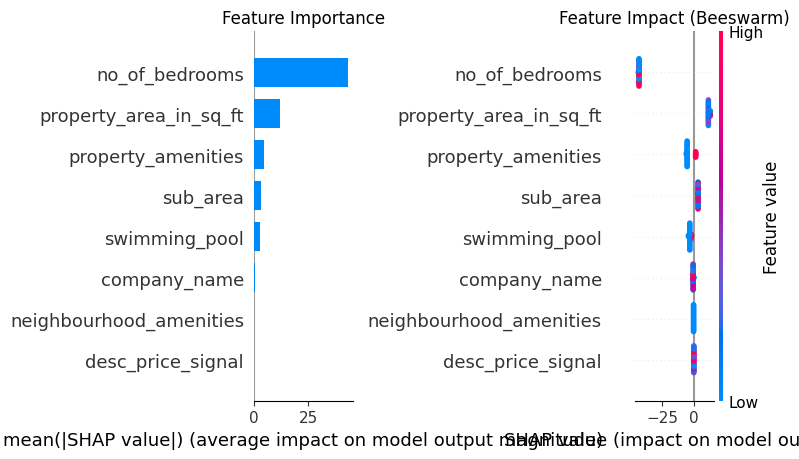

In [4494]:
# SHAP analysis:
import shap

explainer = shap.TreeExplainer(xgb_models['median'])
shap_values = explainer.shap_values(X_test_xgb)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_xgb, plot_type='bar', show=False)
axes[0].set_title('Feature Importance')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_xgb, show=False)
axes[1].set_title('Feature Impact (Beeswarm)')

plt.tight_layout()
plt.show()

Read these SHAP plots as an exploratory view of how the XGBoost benchmark behaves. If Linear QR + CQR remains the winner, its coefficients and interval behavior should be the primary business explanation.

### Ablation: Does `no_of_bedrooms` Help XGBoost?

This is the clean test for whether the feature matters: keep the same split and the same hyperparameters, remove only `no_of_bedrooms`, and compare the resulting metrics.

In [4495]:
xgb_feature_drop = 'no_of_bedrooms'

X_proper_xgb_ablated = X_proper_xgb.drop(columns=[xgb_feature_drop])
X_cal_xgb_ablated = X_cal_xgb.drop(columns=[xgb_feature_drop])
X_test_xgb_ablated = X_test_xgb.drop(columns=[xgb_feature_drop])
# Best params: {'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.7}

xgb_models_ablated = {}
for name, alpha in alphas.items():
    xgb = XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=alpha,
        n_estimators=300,
        max_depth=3,
        learning_rate=0.2,
        min_child_weight=3,
        subsample=0.7,
        random_state=42
    )
    xgb.fit(X_proper_xgb_ablated, y_proper)
    xgb_models_ablated[name] = xgb

xgb_cal_lower_ablated = xgb_models_ablated['lower'].predict(X_cal_xgb_ablated)
xgb_cal_upper_ablated = xgb_models_ablated['upper'].predict(X_cal_xgb_ablated)
xgb_scores_ablated = np.maximum(xgb_cal_lower_ablated - y_cal.values, y_cal.values - xgb_cal_upper_ablated)

n_cal_ablated = len(xgb_scores_ablated)
q_level_ablated = np.ceil((n_cal_ablated + 1) * coverage_level) / n_cal_ablated
xgb_q_hat_ablated = np.quantile(xgb_scores_ablated, min(q_level_ablated, 1.0))

xgb_test_lower_ablated = xgb_models_ablated['lower'].predict(X_test_xgb_ablated) - xgb_q_hat_ablated
xgb_test_upper_ablated = xgb_models_ablated['upper'].predict(X_test_xgb_ablated) + xgb_q_hat_ablated
xgb_test_median_ablated = xgb_models_ablated['median'].predict(X_test_xgb_ablated)

xgb_lower_price_ablated = clip_non_negative_prices(np.expm1(xgb_test_lower_ablated))
xgb_upper_price_ablated = clip_non_negative_prices(np.expm1(xgb_test_upper_ablated))
xgb_median_price_ablated = clip_non_negative_prices(np.expm1(xgb_test_median_ablated))

ablation_comparison = pd.DataFrame([
    {
        'Metric': f'Coverage (target: {coverage_level:.0%})',
        'With no_of_bedrooms': f'{xgb_coverage:.1%}',
        'Without no_of_bedrooms': f"{np.mean((y_test_price >= xgb_lower_price_ablated) & (y_test_price <= xgb_upper_price_ablated)):.1%}",
    },
    {
        'Metric': 'Avg Interval Width',
        'With no_of_bedrooms': f'{xgb_avg_width:.2f} lakhs',
        'Without no_of_bedrooms': f'{np.mean(xgb_upper_price_ablated - xgb_lower_price_ablated):.2f} lakhs',
    },
    {
        'Metric': 'MAE',
        'With no_of_bedrooms': f'{xgb_mae:.2f} lakhs',
        'Without no_of_bedrooms': f'{mean_absolute_error(y_test_price, xgb_median_price_ablated):.2f} lakhs',
    },
    {
        'Metric': 'RMSE',
        'With no_of_bedrooms': f'{xgb_rmse:.2f} lakhs',
        'Without no_of_bedrooms': f'{np.sqrt(mean_squared_error(y_test_price, xgb_median_price_ablated)):.2f} lakhs',
    },
    {
        'Metric': 'R²',
        'With no_of_bedrooms': f'{xgb_r2:.4f}',
        'Without no_of_bedrooms': f'{r2_score(y_test_price, xgb_median_price_ablated):.4f}',
    }
])

show(ablation_comparison)

r2_drop = xgb_r2 - r2_score(y_test_price, xgb_median_price_ablated)
rmse_change = np.sqrt(mean_squared_error(y_test_price, xgb_median_price_ablated)) - xgb_rmse
mae_change = mean_absolute_error(y_test_price, xgb_median_price_ablated) - xgb_mae

print(f"R² drop after removing {xgb_feature_drop}: {r2_drop:.4f}")
print(f"RMSE change after removing {xgb_feature_drop}: {rmse_change:.2f} lakhs")
print(f"MAE change after removing {xgb_feature_drop}: {mae_change:.2f} lakhs")


Loading ITables v2.7.3 from the internet... (need help?)


R² drop after removing no_of_bedrooms: -0.0324
RMSE change after removing no_of_bedrooms: -2.02 lakhs
MAE change after removing no_of_bedrooms: 1.42 lakhs


In [4496]:
# Hyperparameter tuning (XGBoost)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 1.0],
}

xgb_grid = XGBRegressor(
    objective='reg:quantileerror',
    quantile_alpha=0.5,
    random_state=42
)

grid_search = GridSearchCV(
    xgb_grid,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_xgb, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV MAE: {-grid_search.best_score_:.4f}")

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}
Best CV MAE: 0.1487


In [4497]:
# Live model comparison table:
comparison = pd.DataFrame([
    {
        'Metric': f'Coverage (target: {coverage_level:.0%})',
        'Linear QR + CQR': f'{coverage:.1%}',
        'XGBoost + CQR': f'{xgb_coverage:.1%}',
        'Winner': 'Linear QR + CQR' if abs(coverage - coverage_level) <= abs(xgb_coverage - coverage_level) else 'XGBoost + CQR'
    },
    {
        'Metric': 'Avg Interval Width',
        'Linear QR + CQR': f'{avg_width:.2f} lakhs',
        'XGBoost + CQR': f'{xgb_avg_width:.2f} lakhs',
        'Winner': 'Linear QR + CQR' if avg_width <= xgb_avg_width else 'XGBoost + CQR'
    },
    {
        'Metric': 'MAE',
        'Linear QR + CQR': f'{mae:.2f} lakhs',
        'XGBoost + CQR': f'{xgb_mae:.2f} lakhs',
        'Winner': 'Linear QR + CQR' if mae <= xgb_mae else 'XGBoost + CQR'
    },
    {
        'Metric': 'RMSE',
        'Linear QR + CQR': f'{rmse:.2f} lakhs',
        'XGBoost + CQR': f'{xgb_rmse:.2f} lakhs',
        'Winner': 'Linear QR + CQR' if rmse <= xgb_rmse else 'XGBoost + CQR'
    },
    {
        'Metric': 'R²',
        'Linear QR + CQR': f'{r2:.4f}',
        'XGBoost + CQR': f'{xgb_r2:.4f}',
        'Winner': 'Linear QR + CQR' if r2 >= xgb_r2 else 'XGBoost + CQR'
    },
])

show(comparison)

lr_wins = (comparison['Winner'] == 'Linear QR + CQR').sum()
xgb_wins = (comparison['Winner'] == 'XGBoost + CQR').sum()

if lr_wins > xgb_wins:
    print('Linear QR + CQR is the better choice on this split.')
elif xgb_wins > lr_wins:
    print('XGBoost + CQR is the better choice on this split.')
else:
    print('The two models split the metrics on this split.')

print('Treat SHAP below as exploratory diagnostics for XGBoost, not the deployed explanation.')


Loading ITables v2.7.3 from the internet... (need help?)


Linear QR + CQR is the better choice on this split.
Treat SHAP below as exploratory diagnostics for XGBoost, not the deployed explanation.


## Stress-Test Inference Example

This is a deliberately unrealistic input: zero area, zero bedrooms, no amenities, blank description, and unknown categorical values. Use it only as a sanity check for model behavior, not as a business-facing prediction.


In [4498]:
# Extreme all-zero / no-amenity / blank-description example
sample_raw = pd.DataFrame([
    {
        'company_name': 'unknown_company',
        'sub_area': 'baner',
        'description': '',
        'property_area_log': 0.0,
        'no_of_bedrooms': 0.0,
        'swimming_pool': 0,
        'neighbourhood_amenities': 0,
        'property_amenities': 0,
        'desc_price_signal': 0.0
    }
])

sample_lr = sample_raw.copy()
sample_lr['company_name'] = normalize_text(sample_lr['company_name'])
sample_lr['sub_area'] = normalize_text(sample_lr['sub_area'])
sample_lr['te_company_name'] = te_company.transform(sample_lr[['company_name']])
sample_lr['te_sub_area'] = te_sub_area.transform(sample_lr[['sub_area']])
sample_lr = sample_lr.drop(columns=['company_name', 'sub_area', 'description'])
sample_lr = sample_lr[X_train.columns]
sample_lr_scaled = pd.DataFrame(scaler.transform(sample_lr), columns=sample_lr.columns)

lr_lower = clip_non_negative_prices(np.expm1(qr_models['lower'].predict(sample_lr_scaled) - q_hat))[0]
lr_median = clip_non_negative_prices(np.expm1(qr_models['median'].predict(sample_lr_scaled)))[0]
lr_upper = clip_non_negative_prices(np.expm1(qr_models['upper'].predict(sample_lr_scaled) + q_hat))[0]

sample_xgb = pd.DataFrame([
    {
        'property_area_in_sq_ft': 0.0,
        'no_of_bedrooms': 0.0,
        'swimming_pool': 0,
        'neighbourhood_amenities': 0,
        'property_amenities': 0,
        'desc_price_signal': 0.0,
        'company_name': -1,
        'sub_area': -1
    }
])

xgb_lower = clip_non_negative_prices(np.expm1(xgb_models['lower'].predict(sample_xgb) - xgb_q_hat))[0]
xgb_median = clip_non_negative_prices(np.expm1(xgb_models['median'].predict(sample_xgb)))[0]
xgb_upper = clip_non_negative_prices(np.expm1(xgb_models['upper'].predict(sample_xgb) + xgb_q_hat))[0]

sample_input_view = pd.DataFrame([
    {
        'Input setup': 'All zeros / no amenities / blank description / unknown categoricals',
        'company_name': 'unknown_company',
        'sub_area': 'baner',
        'description': '<blank>',
        'property_area': 0.0,
        'bedrooms': 0.0,
        'swimming_pool': 0,
        'neighbourhood_amenities': 0,
        'property_amenities': 0
    }
])

prediction_comparison = pd.DataFrame([
    {
        'Model': 'Linear QR + CQR',
        'Predicted Price': round(lr_median, 2),
        'Lower Bound': round(lr_lower, 2),
        'Upper Bound': round(lr_upper, 2)
    },
    {
        'Model': 'XGBoost + CQR',
        'Predicted Price': round(xgb_median, 2),
        'Lower Bound': round(xgb_lower, 2),
        'Upper Bound': round(xgb_upper, 2)
    }
])

show(sample_input_view)
show(prediction_comparison)


ValueError: feature_names mismatch: ['sub_area', 'property_area_in_sq_ft', 'company_name', 'swimming_pool', 'no_of_bedrooms', 'neighbourhood_amenities', 'property_amenities', 'desc_price_signal'] ['property_area_in_sq_ft', 'no_of_bedrooms', 'swimming_pool', 'neighbourhood_amenities', 'property_amenities', 'desc_price_signal', 'company_name', 'sub_area']

# Feature Pipeline

The deployable preprocessing path has two layers:

1. Deterministic row-wise transforms on raw input rows: rename columns, parse bedrooms, parse area, build amenity scores, drop audit columns.
2. Train-only transforms fit on the training split: text vectorizer, text centroids, target encoders, and scaler.


### Manual LR Artifacts and Inference Helper

In [ ]:
import joblib
import os

RAW_TO_MODEL_COLUMN_MAP = {
    'Sr. No.': 'sr_no',
    'Location': 'location',
    'Sub-Area': 'sub_area',
    'Propert Type': 'property_type',
    'Property Area in Sq. Ft.': 'property_area_in_sq_ft',
    'Price in lakhs': 'price_in_lakhs',
    'Price in Millions': 'price_in_millions',
    'Company Name': 'company_name',
    'TownShip Name/ Society Name': 'township_name_society_name',
    'Total TownShip Area in Acres': 'total_township_area_in_acres',
    'ClubHouse': 'clubhouse',
    'School / University in Township ': 'school_university_in_township',
    'Hospital in TownShip': 'hospital_in_township',
    'Mall in TownShip': 'mall_in_township',
    'Park / Jogging track': 'park_jogging_track',
    'Swimming Pool': 'swimming_pool',
    'Gym': 'gym',
    'Description': 'description'
}

PIPELINE_SPEC = {
    'static_drop_cols': ['sr_no', 'price_in_millions', 'location', 'township_name_society_name'],
    'audit_cols': ['target_correction_note', 'was_target_corrected', 'is_missing_target'],
    'amenity_cols': [
        'clubhouse',
        'school_university_in_township',
        'hospital_in_township',
        'mall_in_township',
        'park_jogging_track',
        'swimming_pool',
        'gym'
    ],
    'neighbourhood_amenity_cols': [
        'mall_in_township',
        'hospital_in_township',
        'school_university_in_township'
    ],
    'property_amenity_cols': ['clubhouse', 'park_jogging_track', 'gym']
}

def apply_deterministic_feature_pipeline(frame):
    frame = frame.copy()
    frame = frame.rename(columns=RAW_TO_MODEL_COLUMN_MAP)
    frame = frame.drop(columns=PIPELINE_SPEC['static_drop_cols'] + PIPELINE_SPEC['audit_cols'], errors='ignore')

    if 'property_type' in frame.columns and 'no_of_bedrooms' not in frame.columns:
        frame['no_of_bedrooms'] = frame['property_type'].apply(extract_bedrooms)
        frame = frame.drop(columns=['property_type'], errors='ignore')

    if 'property_area_in_sq_ft' in frame.columns and 'property_area_log' not in frame.columns:
        frame['property_area_in_sq_ft'] = frame['property_area_in_sq_ft'].apply(parse_area)
        frame['property_area_log'] = np.log1p(frame['property_area_in_sq_ft'])
        frame = frame.drop(columns=['property_area_in_sq_ft'], errors='ignore')

    available_amenity_cols = [col for col in PIPELINE_SPEC['amenity_cols'] if col in frame.columns]
    for col in available_amenity_cols:
        frame[col] = frame[col].replace({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, True: 1, False: 0})
    if available_amenity_cols:
        frame[available_amenity_cols] = frame[available_amenity_cols].fillna(0).astype(int)

    neighbourhood_cols = [col for col in PIPELINE_SPEC['neighbourhood_amenity_cols'] if col in frame.columns]
    property_cols = [col for col in PIPELINE_SPEC['property_amenity_cols'] if col in frame.columns]

    if neighbourhood_cols and 'neighbourhood_amenities' not in frame.columns:
        frame['neighbourhood_amenities'] = frame[neighbourhood_cols].sum(axis=1)
    if property_cols and 'property_amenities' not in frame.columns:
        frame['property_amenities'] = frame[property_cols].sum(axis=1)

    frame = frame.drop(columns=neighbourhood_cols + property_cols, errors='ignore')
    return frame

def prepare_lr_features_for_inference(raw_frame):
    frame = apply_deterministic_feature_pipeline(raw_frame)

    for col in ['company_name', 'sub_area', 'description']:
        if col not in frame.columns:
            frame[col] = ''
        frame[col] = normalize_text(frame[col])

    numeric_defaults = {
        'property_area_log': 0.0,
        'no_of_bedrooms': 0.0,
        'swimming_pool': 0,
        'neighbourhood_amenities': 0,
        'property_amenities': 0,
    }
    for col, default_value in numeric_defaults.items():
        if col not in frame.columns:
            frame[col] = default_value
        frame[col] = pd.to_numeric(frame[col], errors='coerce').fillna(default_value)

    tfidf_matrix = tfidf.transform(frame['description'])
    frame['desc_price_signal'] = (
        cosine_similarity(tfidf_matrix, expensive_centroid).flatten() -
        cosine_similarity(tfidf_matrix, cheap_centroid).flatten()
    )

    frame['te_company_name'] = te_company.transform(frame[['company_name']])
    frame['te_sub_area'] = te_sub_area.transform(frame[['sub_area']])

    frame = frame.drop(columns=['company_name', 'sub_area', 'description'], errors='ignore')
    frame = frame.reindex(columns=X_train.columns, fill_value=0)
    return frame

def predict_lr_interval_from_artifacts(raw_frame, floor=0.0):
    features = prepare_lr_features_for_inference(raw_frame)
    scaled = pd.DataFrame(scaler.transform(features), columns=features.columns, index=features.index)
    lower_log = qr_models['lower'].predict(scaled) - q_hat
    median_log = qr_models['median'].predict(scaled)
    upper_log = qr_models['upper'].predict(scaled) + q_hat
    return pd.DataFrame({
        'Predicted Price': clip_non_negative_prices(np.expm1(median_log)),
        'Lower Bound': clip_non_negative_prices(np.expm1(lower_log)),
        'Upper Bound': clip_non_negative_prices(np.expm1(upper_log))
    }, index=features.index)

# Create artifacts directory
os.makedirs('model_artifacts', exist_ok=True)

# Save manual quantile regression models and preprocessing objects
joblib.dump(qr_models['lower'], 'model_artifacts/qr_lower.pkl')
joblib.dump(qr_models['median'], 'model_artifacts/qr_median.pkl')
joblib.dump(qr_models['upper'], 'model_artifacts/qr_upper.pkl')
joblib.dump(scaler, 'model_artifacts/scaler.pkl')
joblib.dump(te_company, 'model_artifacts/te_company.pkl')
joblib.dump(te_sub_area, 'model_artifacts/te_sub_area.pkl')
joblib.dump(PIPELINE_SPEC, 'model_artifacts/pipeline_spec.pkl')
joblib.dump(list(X_train.columns), 'model_artifacts/model_feature_columns.pkl')
joblib.dump(tfidf, 'model_artifacts/tfidf.pkl')
joblib.dump(expensive_centroid, 'model_artifacts/expensive_centroid.pkl')
joblib.dump(cheap_centroid, 'model_artifacts/cheap_centroid.pkl')
joblib.dump(q_hat, 'model_artifacts/q_hat.pkl')

print('Saved artifacts:')
for f in sorted(os.listdir('model_artifacts')):
    size = os.path.getsize(f'model_artifacts/{f}') / 1024
    print(f'  {f}: {size:.1f} KB')


Saved artifacts:
  cheap_centroid.pkl: 1.0 KB
  expensive_centroid.pkl: 1.0 KB
  lr_pipeline_lower.pkl: 11.9 KB
  lr_pipeline_median.pkl: 11.9 KB
  lr_pipeline_q_hat.pkl: 0.1 KB
  lr_pipeline_upper.pkl: 11.9 KB
  model_feature_columns.pkl: 0.2 KB
  pipeline_spec.pkl: 0.4 KB
  q_hat.pkl: 0.1 KB
  qr_lower.pkl: 1.0 KB
  qr_median.pkl: 1.0 KB
  qr_upper.pkl: 1.0 KB
  scaler.pkl: 1.1 KB
  te_company.pkl: 2.0 KB
  te_sub_area.pkl: 1.7 KB
  tfidf.pkl: 4.4 KB
